# Vanilla GCN on Cora — Kipf & Welling (2017)

A simple, single-file walkthrough of a 2-layer Graph Convolutional Network
trained on the Cora citation dataset, following Kipf & Welling's original
architecture and Hamilton's *Graph Representation Learning* framing.

**Setup:** `pip install torch torch_geometric matplotlib`


In [1]:
!pip install -q torch torch_geometric matplotlib

## 1. Load the Cora dataset

2,708 papers (nodes), 7 classes, 1,433-dim bag-of-words features, ~5,400 citation edges.
We use PyG's built-in `Planetoid` loader with the standard public split
(140 train / 500 val / 1000 test nodes).

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = Planetoid(root="data/Cora", name="Cora", transform=T.NormalizeFeatures())
data = dataset[0].to(device)

print(f"Nodes: {data.num_nodes}, Edges: {data.num_edges}, Features: {dataset.num_node_features}, Classes: {dataset.num_classes}")
print(f"Train/Val/Test nodes: {int(data.train_mask.sum())}/{int(data.val_mask.sum())}/{int(data.test_mask.sum())}")

c:\Users\Sanjeev Srinivas\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Sanjeev Srinivas\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
Processing...


Nodes: 2708, Edges: 10556, Features: 1433, Classes: 7
Train/Val/Test nodes: 140/500/1000


Done!


## 2. Define the Vanilla GCN

Two `GCNConv` layers implement the layer-wise propagation rule derived in
the report:

$$H^{(l+1)} = \sigma\left(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}H^{(l)}W^{(l)}\right)$$

`GCNConv` adds the self-loops ($\tilde{A} = A + I$) internally — this is
the renormalization trick. Two layers means each node aggregates
information from its 2-hop neighborhood.

In [3]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(dataset.num_node_features, hidden_channels=16, out_channels=dataset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


## 3. Train

In [4]:
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    pred = model(data.x, data.edge_index).argmax(dim=1)
    accs = {}
    for split, mask in [("train", data.train_mask), ("val", data.val_mask), ("test", data.test_mask)]:
        accs[split] = (pred[mask] == data.y[mask]).float().mean().item()
    return accs

history = {"loss": [], "train_acc": [], "val_acc": [], "test_acc": []}
best_val_acc, best_test_acc = 0.0, 0.0

for epoch in range(1, 201):
    loss = train()
    accs = evaluate()
    history["loss"].append(loss)
    history["train_acc"].append(accs["train"])
    history["val_acc"].append(accs["val"])
    history["test_acc"].append(accs["test"])

    if accs["val"] > best_val_acc:
        best_val_acc, best_test_acc = accs["val"], accs["test"]

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | loss {loss:.4f} | train {accs['train']:.4f} | val {accs['val']:.4f} | test {accs['test']:.4f}")

print(f"\nBest val accuracy: {best_val_acc:.4f}  |  Test accuracy at best val: {best_test_acc:.4f}")
print("(Kipf & Welling report ~81.5% test accuracy on Cora with this exact setup.)")

Epoch 001 | loss 1.9459 | train 0.3214 | val 0.1440 | test 0.1570
Epoch 020 | loss 1.7174 | train 0.8571 | val 0.5260 | test 0.5360
Epoch 040 | loss 1.3281 | train 0.9643 | val 0.7040 | test 0.7030
Epoch 060 | loss 0.9540 | train 0.9929 | val 0.7600 | test 0.7720
Epoch 080 | loss 0.6925 | train 0.9929 | val 0.7760 | test 0.7900
Epoch 100 | loss 0.5591 | train 0.9929 | val 0.7660 | test 0.7950
Epoch 120 | loss 0.4700 | train 0.9929 | val 0.7740 | test 0.8020
Epoch 140 | loss 0.4071 | train 0.9929 | val 0.7780 | test 0.8010
Epoch 160 | loss 0.3849 | train 1.0000 | val 0.7780 | test 0.8010
Epoch 180 | loss 0.3435 | train 1.0000 | val 0.7780 | test 0.8020
Epoch 200 | loss 0.3223 | train 1.0000 | val 0.7800 | test 0.7990

Best val accuracy: 0.7840  |  Test accuracy at best val: 0.8060
(Kipf & Welling report ~81.5% test accuracy on Cora with this exact setup.)


## 4. Plot training curves

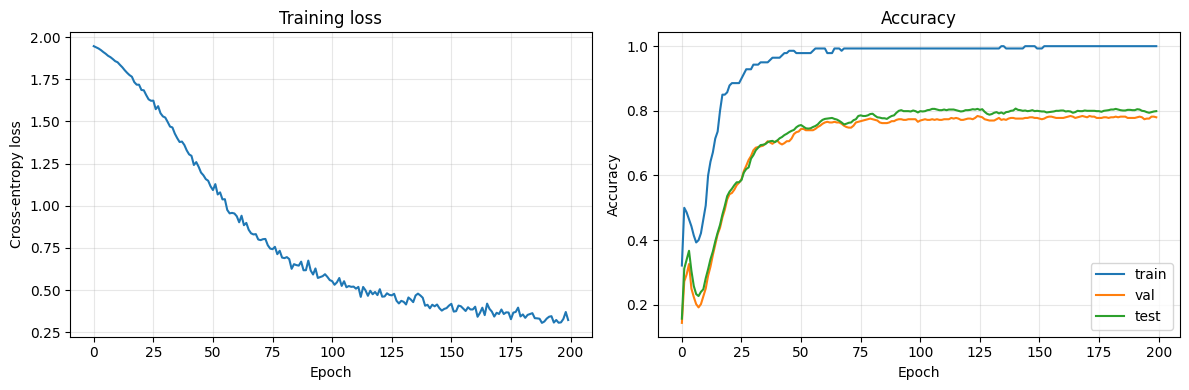

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"])
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].plot(history["test_acc"], label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Over-smoothing demo

Stack untrained GCN layers of increasing depth and measure how similar
node embeddings become. As proven in the report, repeated application of
the normalized propagation matrix acts as a low-pass filter — embeddings
should collapse toward each other as depth increases.

Depth   1 layers -> mean pairwise cosine similarity: 0.0840
Depth   2 layers -> mean pairwise cosine similarity: 0.6141
Depth   4 layers -> mean pairwise cosine similarity: 0.8135
Depth   8 layers -> mean pairwise cosine similarity: 0.9441
Depth  16 layers -> mean pairwise cosine similarity: 0.9994
Depth  32 layers -> mean pairwise cosine similarity: 0.9993
Depth  64 layers -> mean pairwise cosine similarity: 0.0185


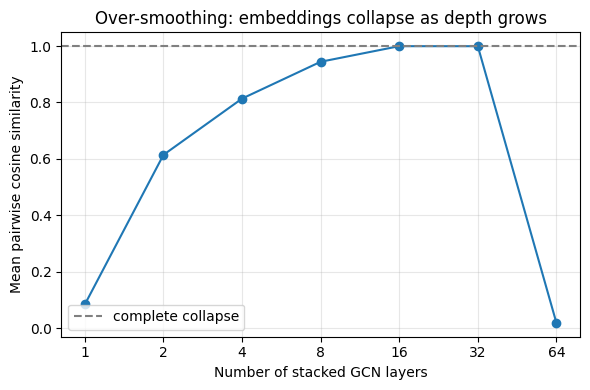

In [6]:
class DeepGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([GCNConv(in_channels, hidden_channels)])
        self.layers.extend(GCNConv(hidden_channels, hidden_channels) for _ in range(num_layers - 1))

    def forward(self, x, edge_index):
        h = x
        for i, layer in enumerate(self.layers):
            h = layer(h, edge_index)
            if i < len(self.layers) - 1:
                h = F.relu(h)
        return h

def mean_pairwise_cosine_similarity(H, sample_size=500):
    idx = torch.randperm(H.shape[0])[:sample_size]
    Hs = F.normalize(H[idx], p=2, dim=1)
    sim = Hs @ Hs.T
    mask = ~torch.eye(sample_size, dtype=torch.bool)
    return sim[mask].mean().item()

depths = [1, 2, 4, 8, 16, 32, 64]
similarities = []

for depth in depths:
    dgcn = DeepGCN(dataset.num_node_features, 16, num_layers=depth).to(device)
    dgcn.eval()
    with torch.no_grad():
        H = dgcn(data.x, data.edge_index)
    sim = mean_pairwise_cosine_similarity(H)
    similarities.append(sim)
    print(f"Depth {depth:>3} layers -> mean pairwise cosine similarity: {sim:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(depths, similarities, marker="o")
plt.xscale("log", base=2)
plt.xticks(depths, [str(d) for d in depths])
plt.xlabel("Number of stacked GCN layers")
plt.ylabel("Mean pairwise cosine similarity")
plt.title("Over-smoothing: embeddings collapse as depth grows")
plt.axhline(1.0, color="gray", linestyle="--", label="complete collapse")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()